In [8]:
# 首先 import 一些主要的包
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.utils.data as Data


device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')


# 获取文件名
file_name = 'train_data.npy'

# 读取数组
data = np.load(file_name)


# 生成题目所需的训练集合
def generate_data(data):
    """
    生成训练数据
    
    Args:
        data (`np.ndarray`): 原始数据数组
        
    Returns:
        x (`np.ndarray`): 输入序列，形状为 [n_samples, 14]
        y (`np.ndarray`): 目标值，形状为 [n_samples]
    """
    # 记录 data 的长度
    n = data.shape[0]

    # 目标是生成可直接用于训练和测试的 x 和 y
    x = []
    y = []

    # 建立 (14 -> 1) 的 x 和 y
    for i in range(15, n):
        x.append(data[i - 15: i - 1])
        y.append(data[i - 1])

    # 转换为 numpy 数组
    x = np.array(x)
    y = np.array(y)

    return x, y


x, y = generate_data(data)
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# 将 y 转化形状
y = torch.unsqueeze(y, dim=1)
print(f'数据形状: x={x.shape}, y={y.shape}')

# 样本总数
num_samples = x.shape[0]
num_train = round(num_samples * 0.8)
num_valid = round(num_samples * 0.1)
num_test = num_samples - num_train - num_valid

print(f'数据集划分: 训练集={num_train}, 验证集={num_valid}, 测试集={num_test}')

dataset = Data.TensorDataset(x, y)
train_data, valid_data, test_data = Data.random_split(dataset, (num_train, num_valid, num_test))

batch_size = 512
train_loader = Data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = Data.DataLoader(valid_data, batch_size=batch_size, shuffle=False)
test_loader = Data.DataLoader(test_data, batch_size=batch_size, shuffle=False)

使用设备: cpu
数据形状: x=torch.Size([1984, 14]), y=torch.Size([1984, 1])
数据集划分: 训练集=1587, 验证集=198, 测试集=199


In [1]:
def compute_mae(y_hat, y):
    return torch.mean(torch.abs(y_hat - y))


def compute_mape(y_hat, y):
    return torch.mean(torch.abs(y_hat - y)/y)


def evaluate_accuracy(data_loader, model):
    # 初始化参数
    mae_sum, mape_sum, n = 0.0, 0.0, 0

    model.eval()
    with torch.no_grad():
        # 对每一个 data_iter 的每一个 x,y 进行计算
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            # 计算模型得出的 y_hat
            y_hat = model(x)

            # 计算对应的 MAE 和 MAPE 对应的和，并乘以 batch 大小
            mae_sum += compute_mae(y_hat, y) * y.shape[0]
            mape_sum += compute_mape(y_hat, y) * y.shape[0]

            # n 用于统计 DataLoader 中一共有多少数量
            n += y.shape[0]

    # 返回时需要除以 batch 大小，得到平均值
    return mae_sum / n, mape_sum / n

使用设备: cpu
数据形状: x=torch.Size([1984, 14]), y=torch.Size([1984, 1])
数据集划分: 训练集=1587, 验证集=198, 测试集=199


In [9]:
# 输入的数量是前 14 个交易日的收盘价
num_inputs = 14
# 输出是下一个交易日的收盘价
num_outputs = 1
# 隐藏层的个数（增加隐藏层大小）
num_hiddens = 256
# LSTM 层数
num_layers = 2
# Dropout 比率
dropout_rate = 0.2


class OptimizedLSTM(nn.Module):
    def __init__(self, num_hiddens, num_layers, num_outputs, dropout_rate=0.2):
        super(OptimizedLSTM, self).__init__()
        # 多层 LSTM，添加 dropout
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=num_hiddens,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Batch Normalization
        self.bn = nn.BatchNorm1d(num_hiddens)
        
        # 更深的全连接层
        self.fc1 = nn.Linear(num_hiddens, num_hiddens // 2)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(num_hiddens // 2, num_hiddens // 4)
        self.fc3 = nn.Linear(num_hiddens // 4, num_outputs)
        
        # 激活函数
        self.relu = nn.ReLU()
        
        # 权重初始化
        self._initialize_weights()
    
    def _initialize_weights(self):
        """初始化模型权重"""
        for name, param in self.named_parameters():
            if 'weight' in name:
                if len(param.shape) >= 2:
                    nn.init.xavier_uniform_(param)
                else:
                    nn.init.uniform_(param, -0.1, 0.1)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    
    def forward(self, x):
        # 重塑输入: [batch_size, seq_len] -> [batch_size, seq_len, 1]
        x = x.view(x.shape[0], -1, 1)
        
        # LSTM 前向传播
        r_out, (h_n, h_c) = self.lstm(x, None)
        
        # 取最后一个时间步的输出
        out = r_out[:, -1, :]  # [batch_size, hidden_size]
        
        # Batch Normalization
        out = self.bn(out)
        
        # 全连接层
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.relu(self.fc2(out))
        out = self.dropout(out)
        out = self.fc3(out)
        
        return out


lstm = OptimizedLSTM(num_hiddens, num_layers, num_outputs, dropout_rate).to(device)
loss_fn = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15, verbose=True, min_lr=1e-6
)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(lstm)
print(f'模型总参数数量: {total_params:,}')
print(f'\n模型结构:')
print(lstm)

模型总参数数量: 833,281

模型结构:
OptimizedLSTM(
  (lstm): LSTM(1, 256, num_layers=2, batch_first=True, dropout=0.2)
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


In [10]:
train_losses, valid_losses, train_maes, train_mapes, valid_maes, valid_mapes = [], [], [], [], [], []

best_valid_loss = float('inf')
best_model_state = None

epochs = 300

for epoch in range(epochs):
    # 初始化参数
    train_l_sum, n = 0.0, 0
    # 初始化时间
    start = time.time()

    lstm.train()

    # 对训练数据集的每个 batch 执行
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        y_hat = lstm(x)
        loss = loss_fn(y_hat, y)
        
        optimizer.zero_grad()
        loss.backward()
        
        # 梯度裁剪：防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(lstm.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_l_sum += loss.item() * y.shape[0]

        # 计数一共有多少个元素
        n += y.shape[0]

    # 模型开启预测状态
    lstm.eval()

    # 同样的，我们可以计算验证集上的 loss
    valid_l_sum, valid_n = 0, 0
    with torch.no_grad():  # 验证时不需要计算梯度
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            y_hat = lstm(x)
            loss = loss_fn(y_hat, y)

            # 对 loss 求和（在下面打印出来）
            valid_l_sum += loss.item() * y.shape[0]

            # 计数一共有多少个元素
            valid_n += y.shape[0]

    # 计算平均损失
    avg_train_loss = train_l_sum / n
    avg_valid_loss = valid_l_sum / valid_n
    
    # 学习率调度
    scheduler.step(avg_valid_loss)
    
    # 对验证集合求指标
    train_mae, train_mape = evaluate_accuracy(train_loader, lstm)
    valid_mae, valid_mape = evaluate_accuracy(valid_loader, lstm)
    
    # 记录最佳模型
    if avg_valid_loss < best_valid_loss:
        best_valid_loss = avg_valid_loss
        best_model_state = lstm.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            'epoch %d, train loss %.6f, valid loss %.6f, train mae %.6f, mape %.6f, valid mae %.6f, mape %.6f, lr %.2e, time %.2f sec'
            % (epoch + 1, avg_train_loss, avg_valid_loss, train_mae, train_mape, valid_mae, valid_mape, current_lr,
               time.time() - start))

    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    train_maes.append(train_mae)
    train_mapes.append(train_mape)
    valid_maes.append(valid_mae)
    valid_mapes.append(valid_mape)

if best_model_state is not None:
    lstm.load_state_dict(best_model_state)
    print(f'\n已加载最佳模型（验证损失: {best_valid_loss:.6f}）')
    print('='*80)

epoch 10, train loss 4.602116, valid loss 4.781144, train mae 4.785980, mape 0.458409, valid mae 5.273211, mape 0.477492, lr 1.00e-03, time 0.60 sec
epoch 20, train loss 1.568414, valid loss 2.898609, train mae 3.246607, mape 0.293810, valid mae 3.380782, mape 0.303185, lr 1.00e-03, time 0.42 sec
epoch 30, train loss 1.138770, valid loss 0.302112, train mae 0.657070, mape 0.067055, valid mae 0.600967, mape 0.063400, lr 1.00e-03, time 0.55 sec
epoch 40, train loss 1.020346, valid loss 0.307499, train mae 0.676487, mape 0.054228, valid mae 0.627288, mape 0.052256, lr 1.00e-03, time 0.46 sec
epoch 50, train loss 0.950506, valid loss 0.221891, train mae 0.562139, mape 0.048479, valid mae 0.525941, mape 0.045729, lr 1.00e-03, time 0.44 sec
epoch 60, train loss 0.886563, valid loss 0.300457, train mae 0.575350, mape 0.050990, valid mae 0.598245, mape 0.053761, lr 1.00e-03, time 0.66 sec
epoch 70, train loss 0.898699, valid loss 0.382373, train mae 0.816463, mape 0.076265, valid mae 0.789578,

In [13]:
import matplotlib
import matplotlib.pyplot as plt

# 设置matplotlib正确显示中文（如宋体，可自行调换为本地存在的支持中文的字体）
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']  
matplotlib.rcParams['axes.unicode_minus'] = False  # 正常显示负号

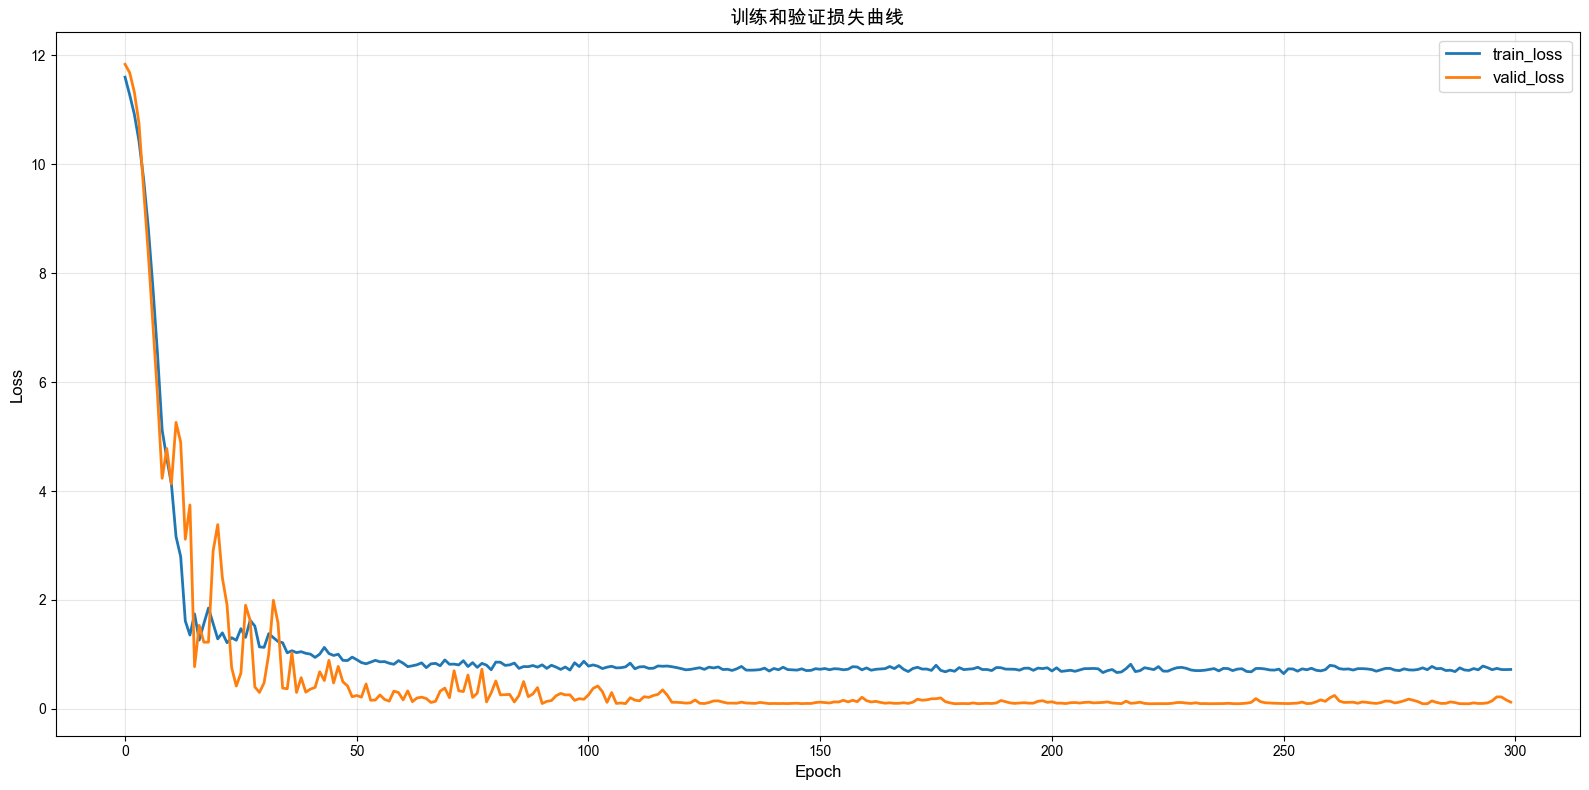

In [14]:
# 绘制训练和验证损失曲线
plt.figure(figsize=(16, 8))

plt.plot(train_losses, label='train_loss', linewidth=2)
plt.plot(valid_losses, label='valid_loss', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('训练和验证损失曲线', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

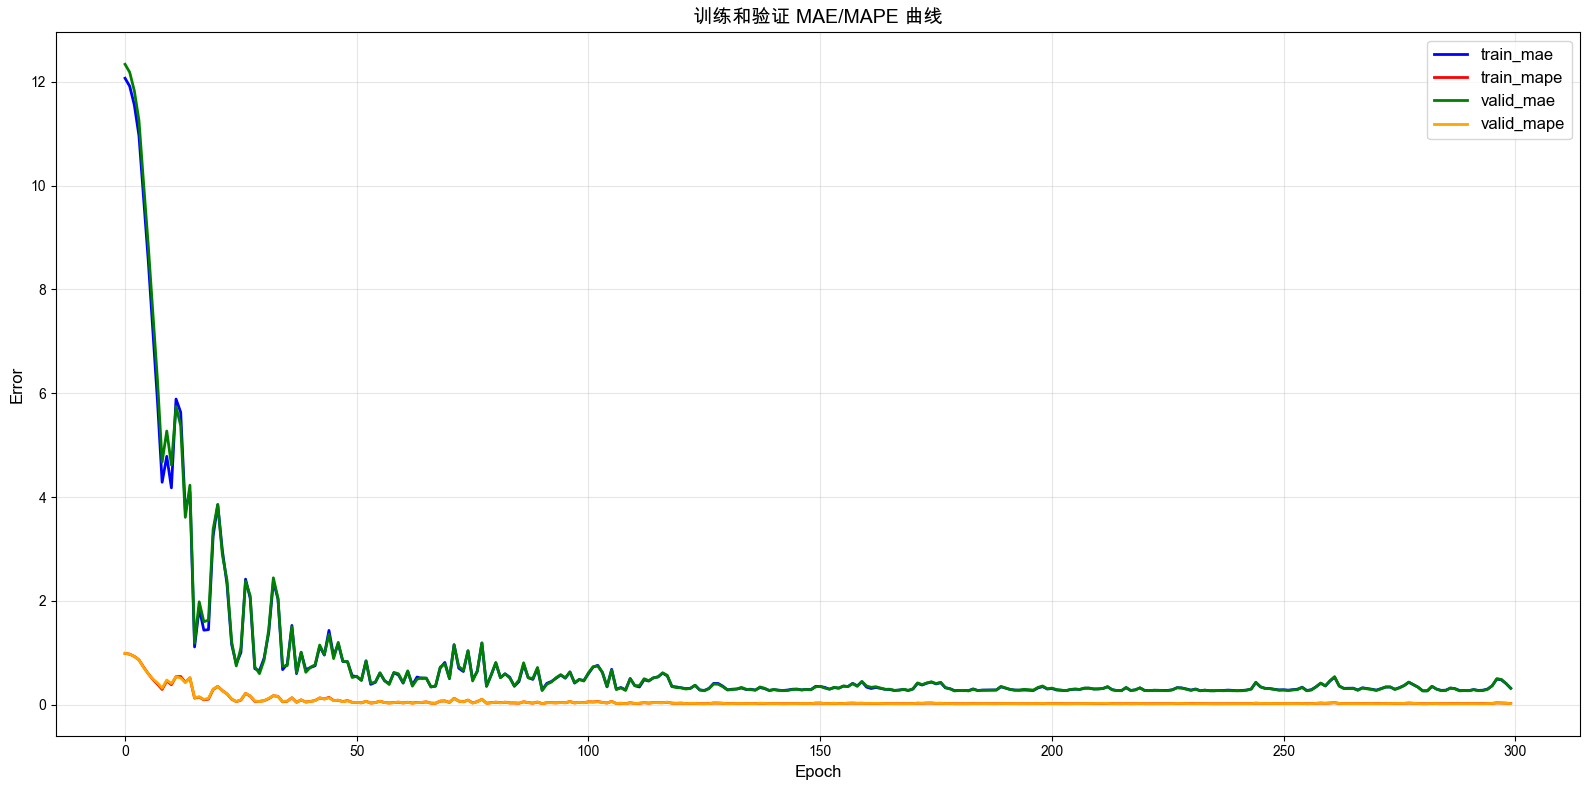

In [15]:
# 绘制 MAE 和 MAPE 曲线
plt.figure(figsize=(16, 8))

# 辅助函数：确保所有待绘制张量都被转换为numpy数组
def to_numpy(arr):
    """将各种类型转换为 numpy 数组"""
    if isinstance(arr, list):
        return np.array([to_numpy(item) for item in arr])
    if hasattr(arr, 'detach') and callable(arr.detach):
        return arr.detach().cpu().numpy()
    if hasattr(arr, 'cpu') and callable(arr.cpu):
        return arr.cpu().numpy()
    return np.array(arr)

# 绘制指标
plt.plot(to_numpy(train_maes), c='blue', label='train_mae', linewidth=2)
plt.plot(to_numpy(train_mapes), c='red', label='train_mape', linewidth=2)
plt.plot(to_numpy(valid_maes), c='green', label='valid_mae', linewidth=2)
plt.plot(to_numpy(valid_mapes), c='orange', label='valid_mape', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('训练和验证 MAE/MAPE 曲线', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# 在测试集上评估最终模型性能
print('\n' + '='*80)
print('测试集性能评估')
print('='*80)

lstm.eval()
test_mae, test_mape = evaluate_accuracy(test_loader, lstm)
print(f'测试集 MAE: {test_mae:.6f}')
print(f'测试集 MAPE: {test_mape:.6f}')

# 同时显示训练集和验证集的最终性能
train_mae_final, train_mape_final = evaluate_accuracy(train_loader, lstm)
valid_mae_final, valid_mape_final = evaluate_accuracy(valid_loader, lstm)

print(f'\n最终性能汇总:')
print(f'训练集 - MAE: {train_mae_final:.6f}, MAPE: {train_mape_final:.6f}')
print(f'验证集 - MAE: {valid_mae_final:.6f}, MAPE: {valid_mape_final:.6f}')
print(f'测试集 - MAE: {test_mae:.6f}, MAPE: {test_mape:.6f}')
print('='*80)



测试集性能评估
测试集 MAE: 0.292326
测试集 MAPE: 0.028648

最终性能汇总:
训练集 - MAE: 0.374312, MAPE: 0.030986
验证集 - MAE: 0.384558, MAPE: 0.030424
测试集 - MAE: 0.292326, MAPE: 0.028648


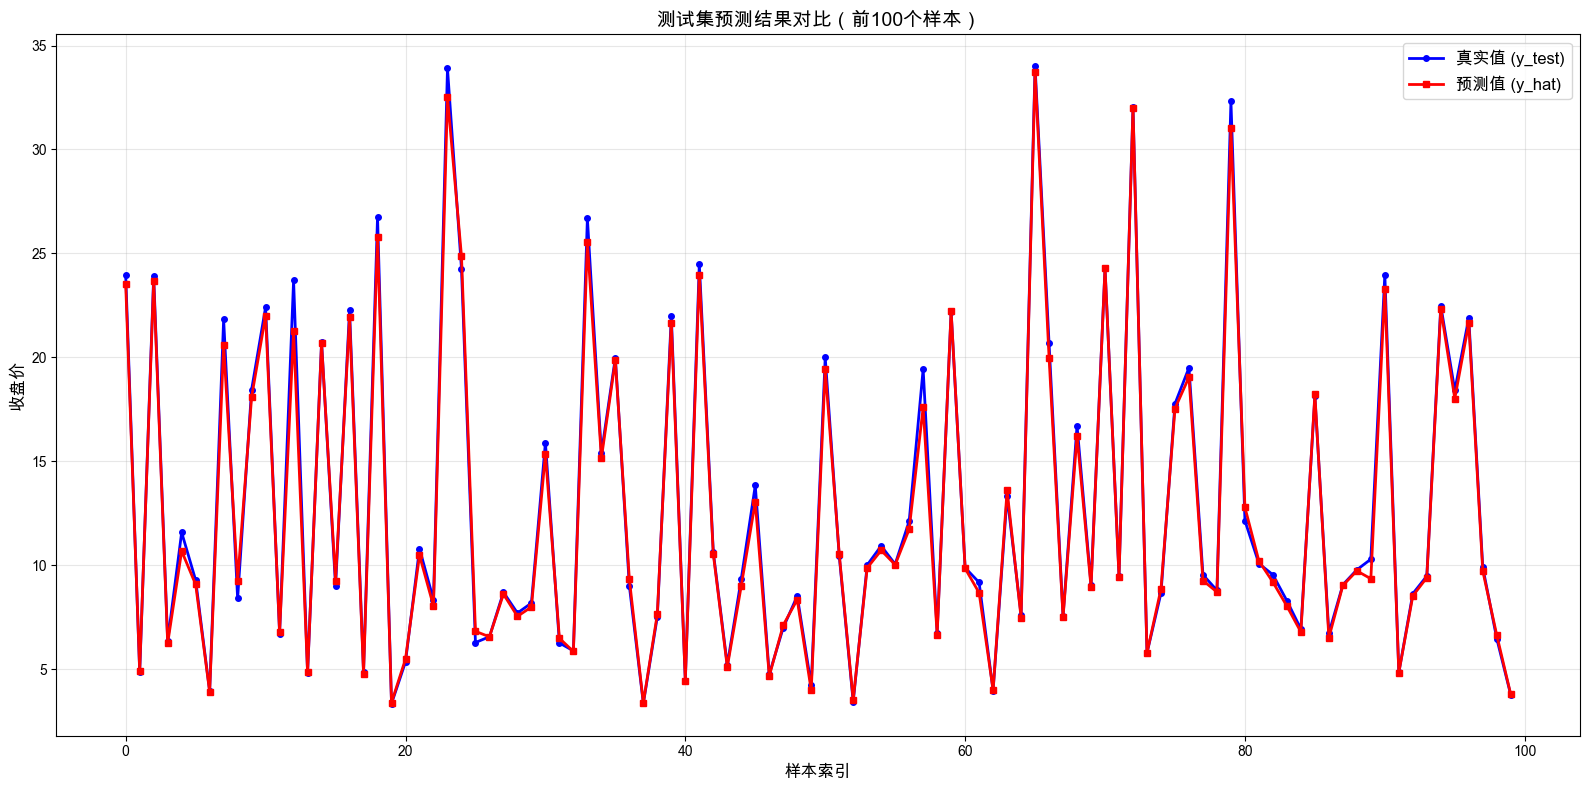


预测误差统计:
平均绝对误差: 0.307954
最大误差: 2.446455
最小误差: 0.001091
误差标准差: 0.350730


In [16]:
# 可视化预测结果
plt.figure(figsize=(16, 8))

# 预测结果
x_test, y_test, y_hat = [], [], []
lstm.eval()
with torch.no_grad():
    for b_x, b_y in test_loader:
        b_x = b_x.to(device)
        y_pred = lstm(b_x).detach().cpu()
        y_test += list(b_y.numpy())
        y_hat += list(y_pred.numpy())

# 绘制前 100 个样本的预测结果
y_test = np.array(y_test).flatten()
y_hat = np.array(y_hat).flatten()

plt.plot(y_test[:100], c='blue', label='真实值 (y_test)', linewidth=2, marker='o', markersize=4)
plt.plot(y_hat[:100], c='red', label='预测值 (y_hat)', linewidth=2, marker='s', markersize=4)

plt.xlabel('样本索引', fontsize=12)
plt.ylabel('收盘价', fontsize=12)
plt.title('测试集预测结果对比（前100个样本）', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 计算预测误差统计
errors = np.abs(y_test - y_hat)
print(f'\n预测误差统计:')
print(f'平均绝对误差: {np.mean(errors):.6f}')
print(f'最大误差: {np.max(errors):.6f}')
print(f'最小误差: {np.min(errors):.6f}')
print(f'误差标准差: {np.std(errors):.6f}')
